In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

## Load Processed Dataset

In [2]:
file_path = r"C:\Users\HP\Desktop\GeoValNet\notebooks\kc_house_data_processed.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_log,geometry
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309987,POINT (-122.257 47.5112)
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,13.195616,POINT (-122.319 47.721)
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,12.100718,POINT (-122.233 47.7379)
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,13.311331,POINT (-122.393 47.5208)
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,13.142168,POINT (-122.045 47.6168)


## Check Dataset

In [4]:
df.shape

(20467, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20467 entries, 0 to 20466
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             20467 non-null  int64  
 1   date           20467 non-null  object 
 2   price          20467 non-null  float64
 3   bedrooms       20467 non-null  int64  
 4   bathrooms      20467 non-null  float64
 5   sqft_living    20467 non-null  int64  
 6   sqft_lot       20467 non-null  int64  
 7   floors         20467 non-null  float64
 8   waterfront     20467 non-null  int64  
 9   view           20467 non-null  int64  
 10  condition      20467 non-null  int64  
 11  grade          20467 non-null  int64  
 12  sqft_above     20467 non-null  int64  
 13  sqft_basement  20467 non-null  int64  
 14  yr_built       20467 non-null  int64  
 15  yr_renovated   20467 non-null  int64  
 16  zipcode        20467 non-null  int64  
 17  lat            20467 non-null  float64
 18  long  

## Feature Engineering

In [ ]:
# House age

current_year = 2026
df['house_age'] = current_year - df['yr_built']

In [7]:
# Renovation Age

df['renovation_age'] = np.where(df['yr_renovated'] == 0, df['house_age'], current_year - df['yr_renovated'])

In [9]:
# Total Rooms

df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [10]:
# Living Area Ratio

df['living_area_ratio'] = df['sqft_living'] / df['sqft_lot']

In [11]:
# Price per Square Foot

df['price_per_sqft'] = df['price'] / df['sqft_living']

In [15]:
# Distance to Seattle City Center

from haversine import haversine, Unit

city_centre = (47.6062, -122.3321)  # Seattle City Center coordinates
distance = []

for _, row in df.iterrows():
    house = (row['lat'], row['long'])
    d = haversine(city_centre, house, unit=Unit.KILOMETERS)
    distance.append(d)

df['distance_to_city_center'] = distance

## Select Features

In [17]:
features = [

    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",

    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",

    "house_age",
    "renovation_age",
    "living_area_ratio",
    "distance_to_city_center",

    "lat",
    "long"
]

X = df[features]

y = df["price"]

## Train-Test Split

In [18]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

## Train XGBoost Regressor

In [19]:
model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, 
                        subsample=0.8, colsample_bytree=0.8, random_state=42)

In [20]:
model.fit(xtrain, ytrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## Predictions

In [21]:
pred = model.predict(xtest)

## Evaluate Model

In [22]:
mape = mean_absolute_percentage_error(ytest, pred)

In [23]:
rsme = np.sqrt(mean_squared_error(ytest, pred))

In [24]:
r2 = r2_score(ytest, pred)

## Print Metrics

In [26]:
print("MAPE :", round(mape * 100, 2), "%")
print("RMSE :", round(rsme, 2))
print("R2 Score :", round(r2, 3))

MAPE : 11.52 %
RMSE : 72487.42
R2 Score : 0.874


## Feature Importance

In [27]:
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})

In [28]:
importance = importance.sort_values(by='Importance', ascending=False)

## Barplot

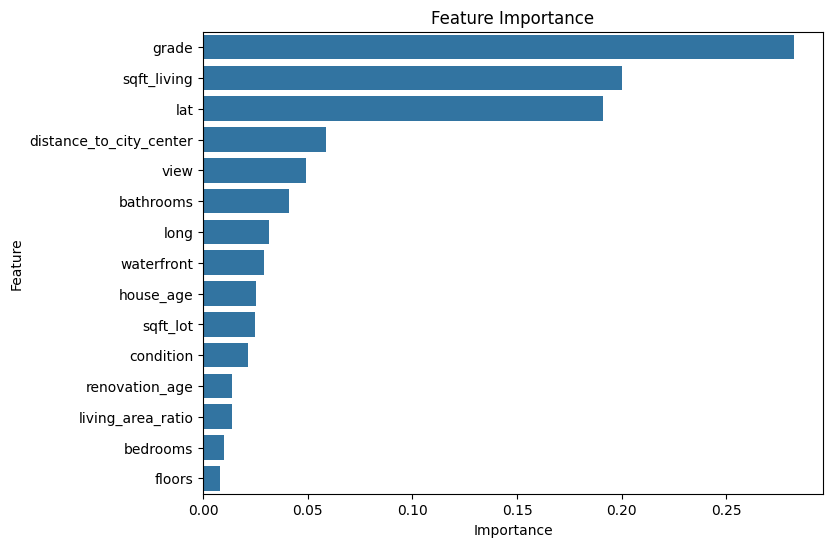

In [29]:
plt.figure(figsize=(8,6))

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")
plt.show()

## Actual vs Predicted

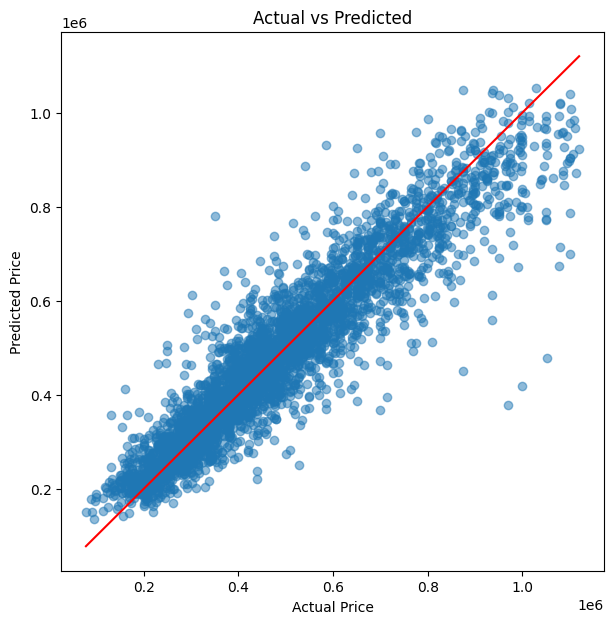

In [36]:
plt.figure(figsize=(7,7))

plt.scatter(ytest, pred, alpha=0.5)

plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

## Residual Plot

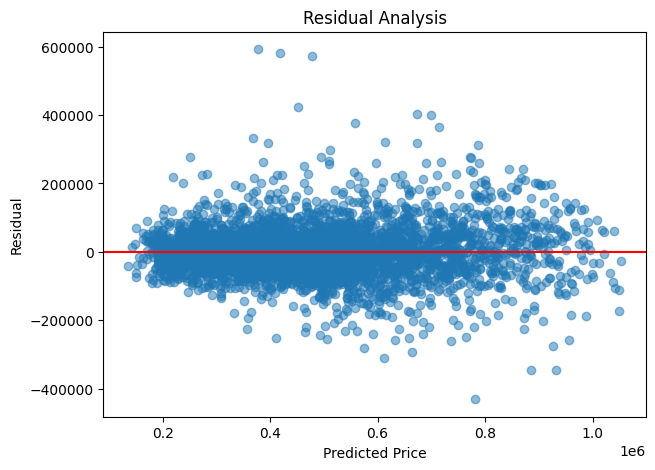

In [33]:
residuals = ytest - pred

plt.figure(figsize=(7,5))
plt.scatter(pred, residuals, alpha=0.5)

plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

## Save the Model

In [34]:
import joblib

joblib.dump(
    model,
    "xgboost_baseline.pkl"
)

['xgboost_baseline.pkl']

## Save the Engineered Dataset

In [35]:
df.to_csv(
    "kc_house_feature_engineered.csv",
    index=False
)